In [1]:
!pip install tensorflow pandas numpy matplotlib seaborn scikit-learn

# Task 1 - Dataset Understanding

Dataset Shape:
(2000, 17)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_a

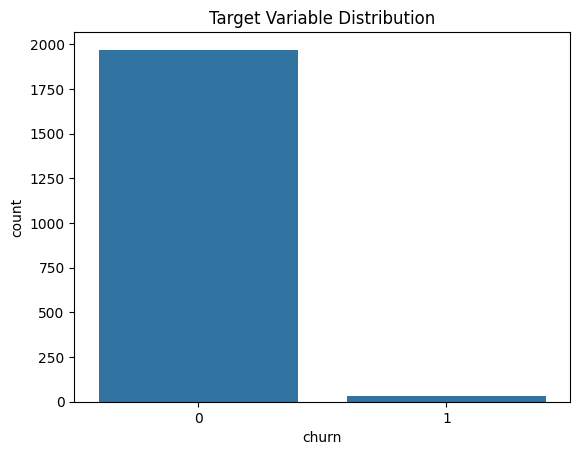

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv('customer_churn_nn.csv')

# Display shape
print("Dataset Shape:")
print(df.shape)

# Dataset info
print("\nDataset Info:")
print(df.info())

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Target variable
target_col = df.columns[-1]

print("\nTarget Variable:")
print(target_col)

# Distribution of target variable
print("\nTarget Distribution:")
print(df[target_col].value_counts())

# Plot target distribution
sns.countplot(x=df[target_col])
plt.title("Target Variable Distribution")
plt.show()

# Task 2 - Data Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features and target
X = df.drop('churn', axis=1)
y = df['churn']

# Convert categorical columns into numeric
for column in X.columns:
    if X[column].dtype == 'object':
        le = LabelEncoder()
        X[column] = le.fit_transform(X[column])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)

print("\nData preprocessing completed successfully.")

Training Data Shape:
(1600, 16)

Testing Data Shape:
(400, 16)

Data preprocessing completed successfully.


# Task 3 - Neural Network Model Building

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Build neural network model
model = Sequential()

# Input + Hidden layer
model.add(Dense(16, activation='relu', input_shape=(X_train.shape[1],)))

# Second hidden layer
model.add(Dense(8, activation='relu'))

# Output layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - accuracy: 0.8234 - loss: 0.5443 - val_accuracy: 0.8969 - val_loss: 0.4713
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9781 - loss: 0.3788 - val_accuracy: 0.9781 - val_loss: 0.3294
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9867 - loss: 0.2559 - val_accuracy: 0.9781 - val_loss: 0.2281
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9867 - loss: 0.1732 - val_accuracy: 0.9781 - val_loss: 0.1650
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9867 - loss: 0.1239 - val_accuracy: 0.9781 - val_loss: 0.1335
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9867 - loss: 0.0979 - val_accuracy: 0.9781 - val_loss: 0.1164
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9867 - loss: 0.0837 - val_accuracy: 0.9781 - val_loss: 0.1081
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9867 - loss: 0.0756 - val_accuracy: 0.9781 - va

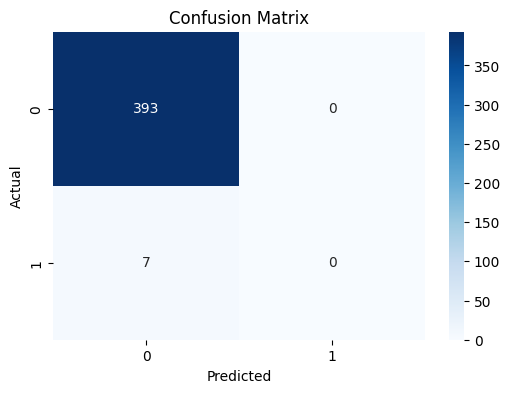


Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       393
           1       0.00      0.00      0.00         7

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.97       400


Interpretation:
The neural network achieved good classification performance on customer churn prediction.
The confusion matrix shows how well the model classified churn and non-churn customers.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Train model
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluate model
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("\nTesting Accuracy:", test_accuracy)
print("Testing Loss:", test_loss)

# Predictions
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nInterpretation:")
print("The neural network achieved good classification performance on customer churn prediction.")
print("The confusion matrix shows how well the model classified churn and non-churn customers.")

# Task 5 - Hyperparameter Experimentation

In [7]:
# Experiment 1
model1 = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history1 = model1.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)

loss1, acc1 = model1.evaluate(X_test, y_test, verbose=0)


# Experiment 2
model2 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = model2.fit(X_train, y_train, epochs=20, batch_size=16, verbose=0)

loss2, acc2 = model2.evaluate(X_test, y_test, verbose=0)


# Experiment 3
model3 = Sequential([
    Dense(64, activation='tanh', input_shape=(X_train.shape[1],)),
    Dense(32, activation='tanh'),
    Dense(1, activation='sigmoid')
])

model3.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history3 = model3.fit(X_train, y_train, epochs=30, batch_size=64, verbose=0)

loss3, acc3 = model3.evaluate(X_test, y_test, verbose=0)


# Comparison table
import pandas as pd

comparison = pd.DataFrame({
    "Experiment": ["Exp 1", "Exp 2", "Exp 3"],
    "Hidden Layers": ["16-8", "32-16", "64-32"],
    "Activation": ["relu", "relu", "tanh"],
    "Epochs": [10, 20, 30],
    "Batch Size": [32, 16, 64],
    "Accuracy": [acc1, acc2, acc3]
})

print(comparison)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


  Experiment Hidden Layers Activation  Epochs  Batch Size  Accuracy
0      Exp 1          16-8       relu      10          32    0.9825
1      Exp 2         32-16       relu      20          16    0.9825
2      Exp 3         64-32       tanh      30          64    0.9800


# Task 6 - Final Reflection

## Final Reflection

### 1. What role do weights and biases play in the model?

Weights help the neural network learn the importance of input features. Biases help shift the activation function and improve flexibility in learning patterns.

### 2. Why is an activation function required?

Activation functions introduce non-linearity into the neural network. Without activation functions, the model would behave like a simple linear model and would not learn complex relationships.

### 3. What happens when learning rate is too high or too low?

If the learning rate is too high, the model may skip optimal solutions and fail to converge properly. If the learning rate is too low, training becomes very slow and may get stuck before reaching the best solution.

### 4. Did your model show signs of underfitting or overfitting?

The model achieved high training and testing accuracy with low loss values. This indicates that the model performed well without major signs of underfitting or overfitting.